# S2 STAR — institutional tearsheet

Frozen Universe D book from `s2_star_stack.json`. No further search.

**Focus:** after a single full-sample equity glance, almost everything below is **OOS** (dates after `RESEARCH_IS_END_STAR`). IS is only for the continuous curve kink, decay ratios, and IS-fit vol tercile cutpoints.

**Contract:** signal at close `t` → fill both legs at open `t+1`. Costs: `US_ALPACA_D_REALISTIC`. Rolling IC is not used — reversion health is ADF / half-life / IS→OOS Sharpe decay.

## 0. Imports & Config

In [1]:
from __future__ import annotations

import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import display

from backtest.s2_coint.diagnosis import (
    check_fill_timing,
    enrich_trades,
    extreme_trades,
    gross_returns_from_net,
    plotly_pair_diagnosis,
    print_extreme_trades,
)
from backtest.s2_coint.report import load_star_stack
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    load_star_panels,
    load_universe_panels,
    lookbacks_for_bar,
    n_trials_ledger_total,
    overlay_ols_hedge,
    repo_root,
    split_is_oos,
    star_panel_paths,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.tearsheet import (
    EVENT_WINDOWS,
    beta_corr_to_benchmark,
    bootstrap_sharpe_ci,
    capacity_table,
    cost_stress_oos_sharpes,
    cvar,
    daily_regime_performance,
    dividend_split_audit,
    equity_from_returns,
    export_s2_period_returns,
    fit_mean_abs_score,
    gap_vs_path_decomposition,
    max_consecutive_losers,
    monthly_returns,
    oos_headline_metrics,
    pair_pnl_attribution,
    pair_scorecard,
    plot_drawdown,
    plot_equity_net_gross,
    plot_event_grid,
    plot_gap_bucket_means,
    plot_losing_months,
    plot_monthly_heatmap,
    plot_static_weekly_overlay,
    plotly_weekly_overlay,
    reversion_health_table,
    split_returns_at_is_end,
    spy_daily_returns,
    utilization_stats,
    weekly_overlay_frame,
    write_star_tearsheet_pdf,
)
from performance.metrics import plot_rolling_metrics, rolling_sharpe_ratio
from strategies.s2_coint.metrics import metrics_from_returns

ROOT = repo_root(ROOT)
STAR_PATH = DEFAULT_STAR_STACK
stack = load_star_stack(STAR_PATH)
UNIVERSE = str(stack["UNIVERSE_STAR"])
BAR = str(stack.get("BAR_STAR") or "1d")
PAIRS = list(stack.get("PAIRS_STAR") or [])
N_TRIALS_LOCAL = 1
N_TRIALS_STACK = n_trials_ledger_total()
PDF_PATH = os.path.join(ARTIFACTS_DIR, "s2_star_tearsheet.pdf")
S2_RETURNS_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s2_coint", "s2_period_returns.parquet"
)
S2_BASE_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s2_coint", "s2_period_returns_base.parquet"
)

print(f"ROOT={ROOT}")
print(f"STAR={STAR_PATH}")
print(f"n_trials_local={N_TRIALS_LOCAL}  n_trials_stack={N_TRIALS_STACK}")
display(pd.Series(stack, name="value").to_frame())


ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
STAR=C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json
n_trials_local=1  n_trials_stack=46


,value
UNIVERSE_STAR,D
BAR_STAR,1d
RESEARCH_IS_END_STAR,2021-12-31
BREAK_STAR,block_05_flat_10
BOOK_STAR,freeze
PAIRS_STAR,"[WSO|WSO.B, HEI|HEI.A, NWS|NWSA]"
OLS_WINDOW_STAR,252
ADF_WINDOW_STAR,252
ENTRY_Z_STAR,1.5
Z_WINDOW_STAR,90


## 1. Contract

In [2]:
print("Timing: close-t signal → open-(t+1) fill (both legs)")
print(f"Cost profile: {stack.get('COST_PROFILE_STAR') or 'US_ALPACA_D_REALISTIC (Universe D default)'}")
print("Not modelled: HTB locate spikes, vol-scaled slippage, single-leg dividends in PnL, overnight auction microstructure")
print(f"Pairs: {PAIRS}")
print(f"Research IS end: {stack.get('RESEARCH_IS_END_STAR')}")


Timing: close-t signal → open-(t+1) fill (both legs)
Cost profile: US_ALPACA_D_REALISTIC (Universe D default)
Not modelled: HTB locate spikes, vol-scaled slippage, single-leg dividends in PnL, overnight auction microstructure
Pairs: ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']
Research IS end: 2021-12-31


## 2. Run

`mean_abs_score` is the in-sample mean of `|z|` used to scale score-based position size so a typical signal is order-1; it is frozen on IS and not refit on OOS.

In [3]:
# Load STAR panels when cached; else rebuild OLS overlay from census panel.
try:
    train, full, manifest = load_star_panels(
        universe=UNIVERSE, bar=BAR, pair_ids=PAIRS, root=ROOT
    )
    print("loaded star panels", manifest.get("stack_hash"))
except (FileNotFoundError, ValueError) as exc:
    warnings.warn(f"star panels unavailable ({exc}); overlaying OLS from census panel")
    train, full = load_universe_panels(UNIVERSE, BAR, PAIRS, root=ROOT)
    lb = lookbacks_for_bar(
        BAR,
        ols_days=int(stack.get("OLS_WINDOW_STAR") or 252),
        z_days=int(stack.get("Z_WINDOW_STAR") or 90),
        adf_days=int(stack.get("ADF_WINDOW_STAR") or 252),
    )
    train = overlay_ols_hedge(
        train,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )
    full = overlay_ols_hedge(
        full,
        ols_window=lb["ols_window"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
    )

IS_END = is_end_for_stack(stack, full)
is_panel, oos_panel = split_is_oos(full, is_end=IS_END)
cfg = config_from_stack(stack)
mean_abs = fit_mean_abs_score(is_panel, score_column=cfg.score_column)
s1_weekly = load_s1_weekly(ROOT)
spy = spy_daily_returns(full["date"].min(), full["date"].max())

print(f"IS_END={IS_END.date()}  mean_abs_score={mean_abs:.4f}")
print(f"full rows={len(full)}  IS={len(is_panel)}  OOS={len(oos_panel)}")
print(f"cost_profile={cfg.cost_profile}  size_mode={cfg.size_mode}  vol_mode={cfg.vol_mode}")

full_res = run_s2_backtest(
    full,
    cfg,
    s1_weekly=s1_weekly,
    mean_abs_score=mean_abs,
    n_trials_local=N_TRIALS_LOCAL,
    n_trials_stack=N_TRIALS_STACK,
)
oos_res = run_s2_backtest(
    oos_panel,
    cfg,
    s1_weekly=s1_weekly,
    mean_abs_score=mean_abs,
    n_trials_local=N_TRIALS_LOCAL,
    n_trials_stack=N_TRIALS_STACK,
)

full_net = full_res.returns
oos_net = oos_res.returns
oos_gross = gross_returns_from_net(oos_net, oos_res.pair_trades)
is_net, _ = split_returns_at_is_end(full_net, IS_END)

# Enrich OOS trades with signal context
oos_trades_enriched_parts = []
for pid, pr in oos_res.book.pair_results.items():
    g = oos_panel.loc[oos_panel["pair_id"].astype(str) == str(pid)]
    enr = enrich_trades(pr.trades, g, pr.returns)
    if not enr.empty:
        oos_trades_enriched_parts.append(enr)
oos_trades = (
    pd.concat(oos_trades_enriched_parts, ignore_index=True)
    if oos_trades_enriched_parts
    else pd.DataFrame()
)

print("full metrics", full_res.metrics)
print("oos metrics", oos_res.metrics)
print(f"OOS trades={len(oos_trades)}")


C:\Users\User\AppData\Local\Temp\ipykernel_116152\3861869681.py:8: UserWarning: star panels unavailable (missing c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_panel_D_1d_train_star.parquet. Run build_star_panels.ipynb after H-005/H-006 freeze.); overlaying OLS from census panel
  warnings.warn(f"star panels unavailable ({exc}); overlaying OLS from census panel")


IS_END=2021-12-31  mean_abs_score=0.9357
full rows=19669  IS=16177  OOS=3492
cost_profile=US_ALPACA_D_REALISTIC  size_mode=score  vol_mode=s1_vt
full metrics {'ann_sharpe': 1.360607974143827, 'max_drawdown': -0.05777072686144402, 'n_days': 9228, 'psr': 1.0, 'dsr_local': 1.0, 'dsr_stack': 1.0, 'skew': 2.2845971993774157, 'excess_kurtosis': 35.22019197564745, 'n_trials_local': 1, 'n_trials_stack': 46, 'corr_to_s1': -0.08045098247594352}
oos metrics {'ann_sharpe': 1.330831086279795, 'max_drawdown': -0.03367738684124777, 'n_days': 1164, 'psr': 0.9945191153785289, 'dsr_local': 1.0, 'dsr_stack': 1.0, 'skew': 4.9267429923273225, 'excess_kurtosis': 54.97186563978817, 'n_trials_local': 1, 'n_trials_stack': 46, 'corr_to_s1': -0.05680926617851829}
OOS trades=52


## 3. Full-sample glance (then stop using it)

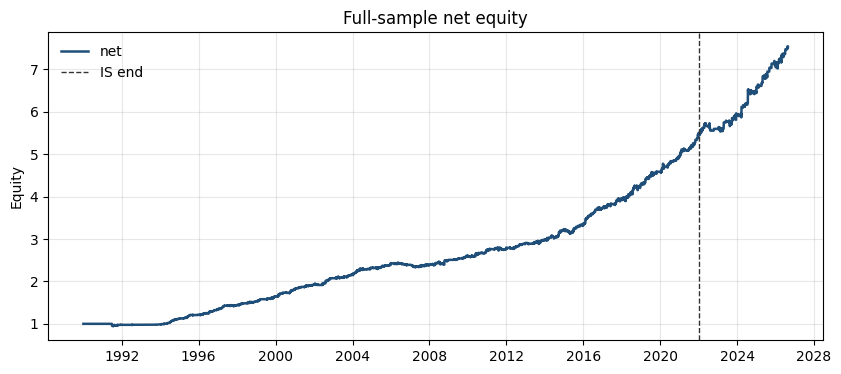

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
eq = equity_from_returns(full_net)
ax.plot(eq.index, eq.values, color="#1f4e79", lw=1.8, label="net")
ax.axvline(IS_END, color="#333333", ls="--", lw=1.0, zorder=5, label="IS end")
ax.set_title("Full-sample net equity")
ax.set_ylabel("Equity")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.show()


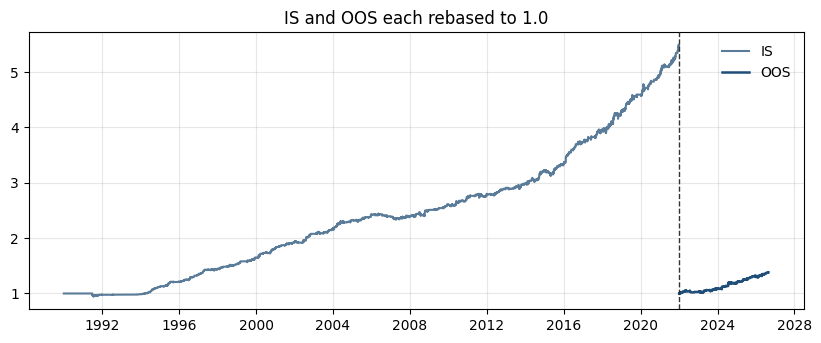

,value
IS_sharpe,1.375810
OOS_sharpe,1.330831
OOS_over_IS,0.967307


In [5]:
fig, ax = plt.subplots(figsize=(10, 3.6))
is_eq = equity_from_returns(is_net)
oos_eq = equity_from_returns(oos_net)
if not is_eq.empty:
    ax.plot(is_eq.index, is_eq.values, color="#5b7c99", lw=1.5, label="IS")
if not oos_eq.empty:
    ax.plot(oos_eq.index, oos_eq.values, color="#1f4e79", lw=1.8, label="OOS")
ax.axvline(IS_END, color="#333333", ls="--", lw=1.0, zorder=5)
ax.set_title("IS and OOS each rebased to 1.0")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
plt.show()

is_m = metrics_from_returns(is_net)
oos_m = metrics_from_returns(oos_net)
decay = pd.Series(
    {
        "IS_sharpe": is_m["ann_sharpe"],
        "OOS_sharpe": oos_m["ann_sharpe"],
        "OOS_over_IS": (
            oos_m["ann_sharpe"] / is_m["ann_sharpe"]
            if np.isfinite(is_m["ann_sharpe"]) and abs(is_m["ann_sharpe"]) > 1e-12
            else float("nan")
        ),
    }
)
display(decay.to_frame("value"))


## 4. OOS headline

In [6]:
headline = oos_headline_metrics(
    oos_net,
    oos_gross,
    trades=oos_res.pair_trades,
    s1_weekly=s1_weekly,
    spy_daily=spy,
    n_trials_local=N_TRIALS_LOCAL,
    n_trials_stack=N_TRIALS_STACK,
)
display(headline.to_frame("OOS"))


,OOS
ann_sharpe_net,1.330831
ann_sharpe_gross,1.801770
sortino,2.851503
calmar,2.153151
max_drawdown,-0.033677
cagr,0.072513
total_return,0.381752
psr,0.994519
dsr_local,1.000000
dsr_stack,1.000000


## 5. OOS standalone performance

### 5.1 OOS equity (net vs gross)

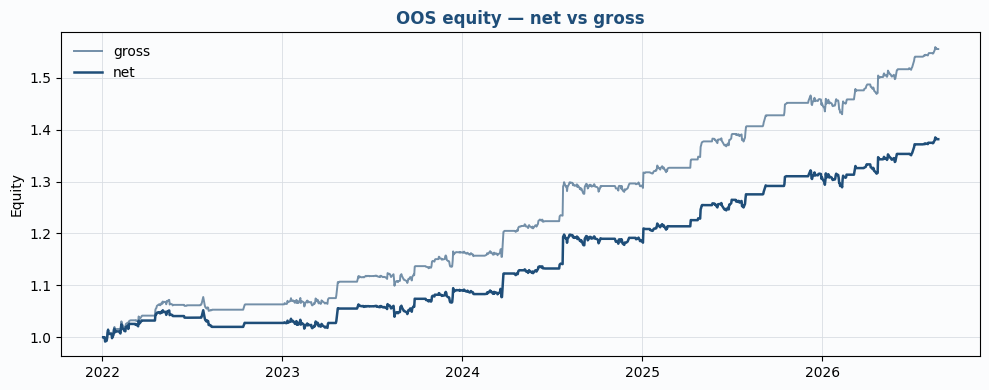

In [7]:
fig = plot_equity_net_gross(oos_net, oos_gross, title="OOS equity — net vs gross")
plt.show()


### 5.2 Drawdown

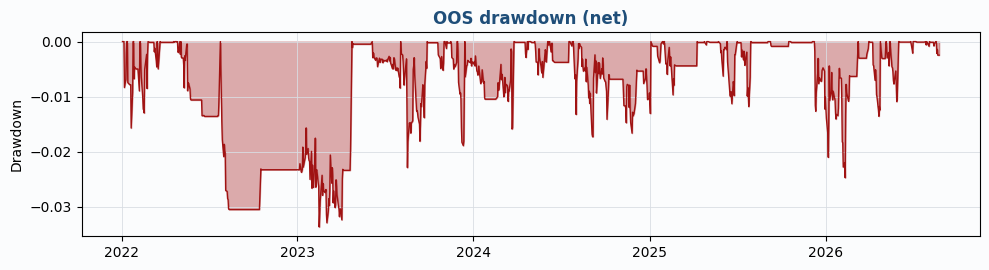

In [8]:
fig = plot_drawdown(oos_net, title="OOS drawdown (net)")
plt.show()


### 5.3 Rolling Sharpe

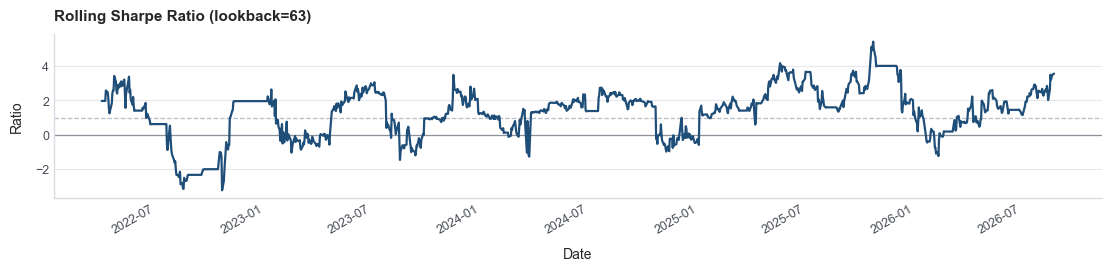

In [9]:
plot_rolling_metrics(oos_net, 63, metrics=("sharpe",))


### 5.4 Monthly heatmap

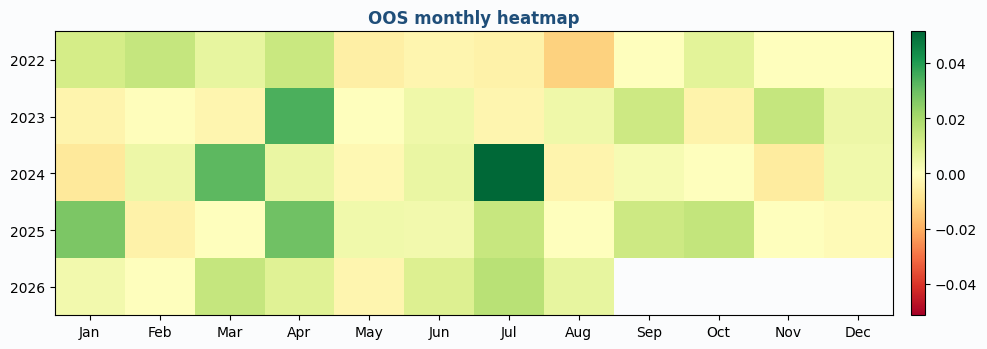

In [10]:
oos_monthly = monthly_returns(oos_net)
fig = plot_monthly_heatmap(oos_monthly, title="OOS monthly heatmap")
plt.show()


### 5.5 Return distribution

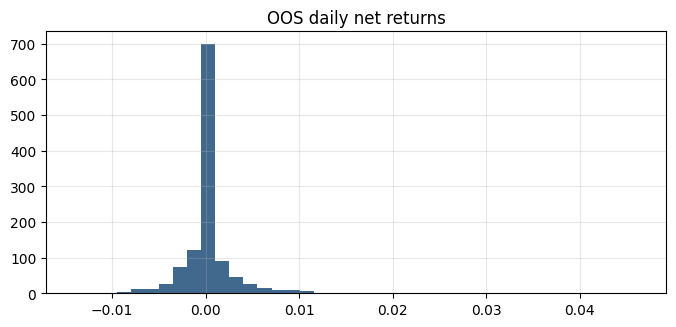

,ret
date,
2024-03-21,-0.014055
2023-08-17,-0.011536
2025-12-10,-0.009840
2023-02-08,-0.009074
2022-05-18,-0.008513
2023-08-16,-0.008388
2022-01-07,-0.008343
2025-07-22,-0.008017
2022-01-21,-0.007936


In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(oos_net.dropna(), bins=40, color="#1f4e79", alpha=0.85)
ax.set_title("OOS daily net returns")
ax.grid(True, alpha=0.3)
plt.show()
worst_days = oos_net.nsmallest(10).to_frame("ret")
display(worst_days)


## 6. Overlay (secondary)

In [12]:
weekly_full = weekly_overlay_frame(full_net, s1_weekly, spy)
weekly_oos = weekly_overlay_frame(oos_net, s1_weekly, spy)
print(f"weekly_full n={len(weekly_full)}  weekly_oos n={len(weekly_oos)}")

try:
    fig = plotly_weekly_overlay(weekly_full, weekly_oos, title="S2 vs S1 vs SPY (weekly)")
    fig.show()
except Exception as exc:
    warnings.warn(f"plotly overlay failed ({exc}); static fallback")
    fig = plot_static_weekly_overlay(weekly_oos, title="S2 vs S1 vs SPY — OOS weekly", is_end=IS_END)
    plt.show()


weekly_full n=591  weekly_oos n=237


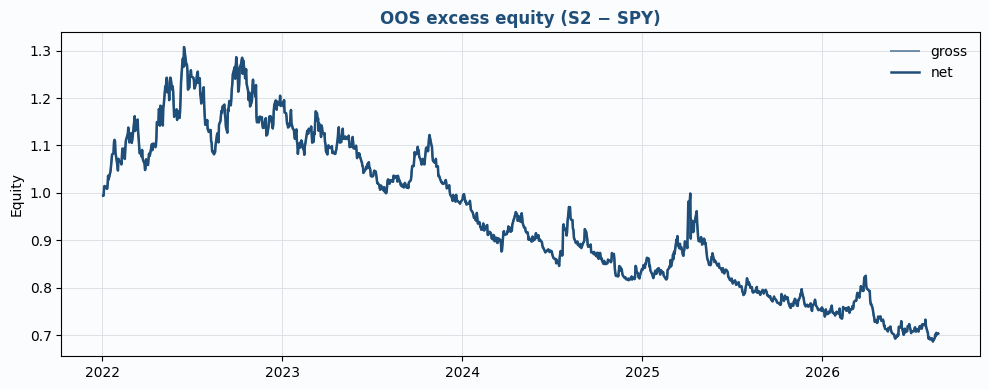

,value
beta,0.010494
corr,0.034136
n,1164.000000


In [13]:
# Excess S2 − SPY (daily OOS) and beta/corr readout
spy_oos = spy.reindex(oos_net.index).fillna(0.0)
excess = (oos_net.fillna(0.0) - spy_oos).rename("excess")
fig = plot_equity_net_gross(excess, excess, title="OOS excess equity (S2 − SPY)")
plt.show()
display(pd.Series(beta_corr_to_benchmark(oos_net, spy), name="value").to_frame())


## 7. OOS losing months

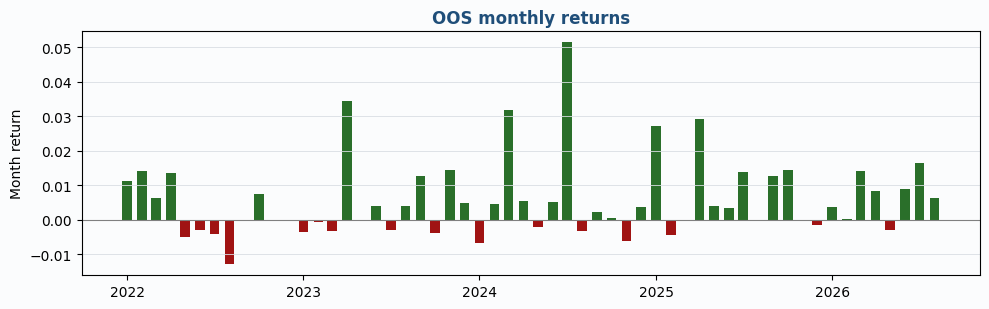

,monthly_return
2022-08-01,-0.012918
2024-01-01,-0.006845
2024-11-01,-0.006280
2022-05-01,-0.005037
2025-02-01,-0.004404
2022-07-01,-0.004171
2023-10-01,-0.003736
2023-01-01,-0.003441
2024-08-01,-0.003336
2023-03-01,-0.003147


In [14]:
fig = plot_losing_months(oos_monthly, title="OOS monthly returns")
plt.show()
display(oos_monthly.sort_values().head(10).to_frame("monthly_return"))


## 8. OOS regimes

In [15]:
is_dates = pd.DatetimeIndex(pd.to_datetime(is_panel["date"])).unique()
regimes = daily_regime_performance(oos_net, spy, is_dates)
print("Vol cutpoints (IS):")
display(regimes["vol_cutpoints"].to_frame("value"))
print("By market direction:")
display(regimes["market"])
print("By vol tercile:")
display(regimes["vol"])


Vol cutpoints (IS):


,value
q33,0.007221
q66,0.010946


By market direction:


,n,mean_return,total_return,sharpe,win_rate
regime,,,,,
Down,539,0.000263,0.147963,1.144364,0.244898
Up,625,0.000302,0.203656,1.523367,0.289600


By vol tercile:


,n,mean_return,total_return,sharpe,win_rate
regime,,,,,
High,337,0.000130,0.043580,0.819269,0.201780
Low,267,0.000515,0.144105,1.765787,0.258427
Mid,560,0.000266,0.157279,1.350306,0.314286


## 9. Event study

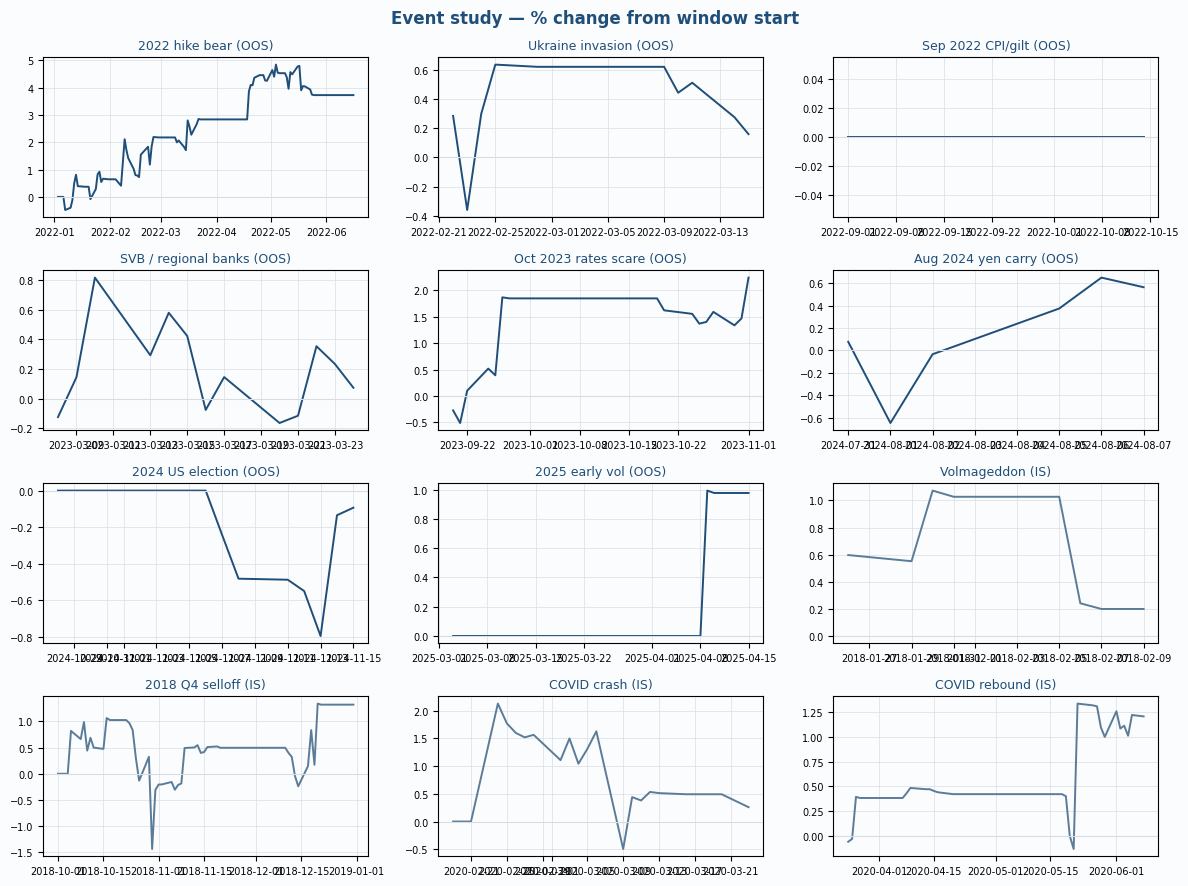

In [16]:
fig = plot_event_grid(full_net, is_end=IS_END, windows=EVENT_WINDOWS)
plt.show()


## 10. Reversion health (no IC)

,pair_id,window,pct_adf_lt_threshold,median_half_life,beta_std,n_days
0,WSO|WSO.B,IS,93.163184,1.580584,0.250033,8064
1,WSO|WSO.B,OOS,99.140893,5.233368,0.166955,1164
2,HEI|HEI.A,IS,20.347985,11.147576,0.175773,5962
3,HEI|HEI.A,OOS,14.089347,14.254620,0.156451,1164
4,NWS|NWSA,IS,36.567617,5.979501,0.074869,2151
5,NWS|NWSA,OOS,16.065292,19.822413,0.171658,1164


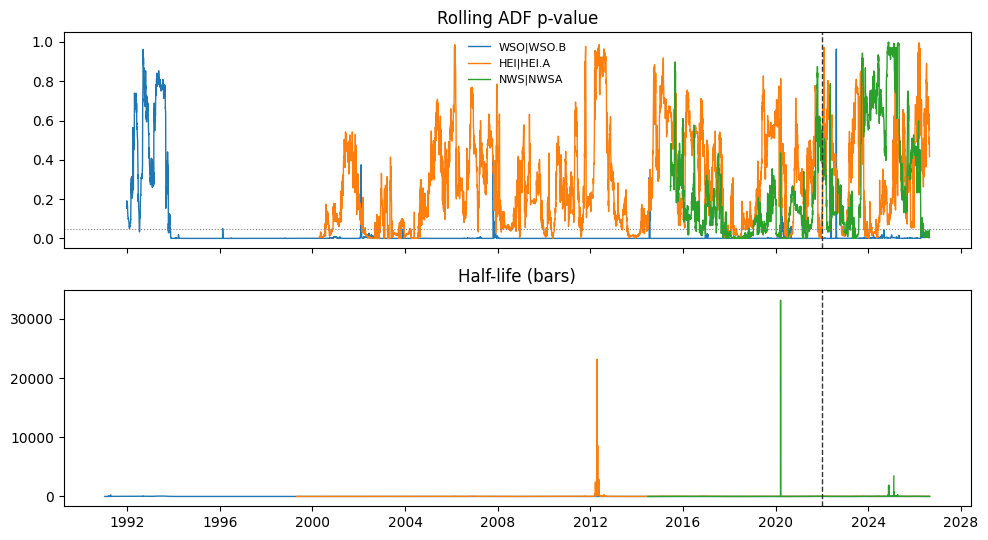

IS Sharpe=1.376 → OOS Sharpe=1.331 (ratio=0.967)


In [17]:
health = reversion_health_table(full, is_end=IS_END)
display(health)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for pid, g in full.groupby("pair_id", sort=False):
    g = g.sort_values("date")
    axes[0].plot(g["date"], g["adf_pvalue"], lw=1.0, label=str(pid))
    axes[1].plot(g["date"], g["half_life"], lw=1.0, label=str(pid))
axes[0].axhline(0.05, color="gray", ls=":", lw=0.8)
axes[0].axvline(IS_END, color="#333333", ls="--", lw=1.0)
axes[1].axvline(IS_END, color="#333333", ls="--", lw=1.0)
axes[0].set_title("Rolling ADF p-value")
axes[1].set_title("Half-life (bars)")
axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

print(
    f"IS Sharpe={is_m['ann_sharpe']:.3f} → OOS Sharpe={oos_m['ann_sharpe']:.3f} "
    f"(ratio={decay['OOS_over_IS']:.3f})"
)


## 11. OOS pair scorecard

,pair_id,ann_sharpe_net,ann_sharpe_gross,max_drawdown,n_trades,cost_bps_year,pct_adf_lt_05,n_days
0,WSO|WSO.B,1.905639,2.001724,-0.239189,41,421.412522,99.140893,559
1,HEI|HEI.A,-0.609959,-0.244749,-0.045247,5,368.307692,14.089347,78
2,NWS|NWSA,-1.606333,-1.130804,-0.068706,6,441.969231,16.065292,78


,oos_total_return
NWS|NWSA,-0.047313
HEI|HEI.A,-0.020313
WSO|WSO.B,4.156033


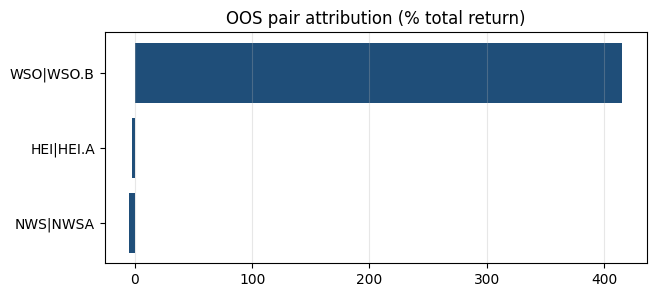

In [18]:
scorecard = pair_scorecard(oos_res.book.pair_results, full, is_end=IS_END)
display(scorecard)
attr = pair_pnl_attribution(oos_res.book.pair_results, is_end=IS_END)
display(attr.to_frame("oos_total_return"))
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(attr.index), 100.0 * attr.values, color="#1f4e79")
ax.set_title("OOS pair attribution (% total return)")
ax.grid(True, axis="x", alpha=0.3)
plt.show()


## 12. Trades — losing first

In [19]:
N_EXTREME_TRADES = 7  # edit this constant to show more/fewer extreme trades

best, worst = extreme_trades(oos_trades, n=N_EXTREME_TRADES)
print(f"=== Worst {N_EXTREME_TRADES} OOS trades ===")
display(worst)
print(f"=== Best {N_EXTREME_TRADES} OOS trades ===")
display(best)

# Drivers for large |pnl| trades (~20%+)
big = oos_trades.loc[oos_trades["pnl_pct"].abs() >= 20.0].sort_values("pnl_pct")
if not big.empty:
    print("Large |pnl| >= 20% — drivers")
    cols = [
        c
        for c in [
            "pair_id",
            "side_label",
            "entry_date",
            "exit_date",
            "pnl_pct",
            "exit_reason",
            "z_entry",
            "z_exit",
            "adf_entry",
            "adf_exit",
            "hold_bars",
        ]
        if c in big.columns
    ]
    display(big[cols])
else:
    print("No OOS trades with |pnl_pct| >= 20")


=== Worst 7 OOS trades ===


,pair_id,side,side_label,entry_date,exit_date,hold_bars,entry_cost_bps,exit_cost_bps,exit_reason,signal_date,exit_signal_date,z_entry,z_exit,spread_entry,spread_exit,adf_entry,adf_exit,pnl_pct
0,WSO|WSO.B,-1,short,2022-07-20,2022-08-04,11,11.4,11.4,coint_break,2022-07-19,2022-08-03,1.711670,2.641252,0.053546,0.114252,0.000003,0.000215,-7.289034
1,WSO|WSO.B,1,long,2022-05-10,2022-05-25,11,11.4,11.4,coint_break,2022-05-09,2022-05-24,-1.506213,-2.187502,-0.047335,-0.083818,0.000002,0.187252,-5.245188
2,WSO|WSO.B,-1,short,2022-08-05,2022-08-08,1,11.4,11.4,coint_break,2022-08-04,2022-08-05,2.600147,2.709768,0.118583,0.130663,0.000351,0.000799,-5.138270
3,NWS|NWSA,1,long,2022-04-25,2022-05-06,9,11.4,11.4,coint_break,2022-04-22,2022-05-05,-1.683817,-2.830159,-0.009571,-0.041029,0.045725,0.156329,-4.559639
4,WSO|WSO.B,1,long,2024-07-26,2024-10-10,53,11.4,11.4,mean_revert,2024-07-25,2024-10-09,-2.966224,0.026928,-0.081825,-0.011359,0.001878,0.004741,-4.188261
5,HEI|HEI.A,-1,short,2023-12-15,2024-01-25,26,11.4,11.4,coint_break,2023-12-14,2024-01-24,1.795037,2.118193,-0.000059,0.015015,0.042711,0.187339,-3.140710
6,WSO|WSO.B,1,long,2022-06-17,2022-06-22,2,11.4,11.4,mean_revert,2022-06-16,2022-06-21,-3.057879,0.007193,-0.125321,-0.012280,0.000143,0.000001,-2.009378


=== Best 7 OOS trades ===


,pair_id,side,side_label,entry_date,exit_date,hold_bars,entry_cost_bps,exit_cost_bps,exit_reason,signal_date,exit_signal_date,z_entry,z_exit,spread_entry,spread_exit,adf_entry,adf_exit,pnl_pct
0,WSO|WSO.B,-1,short,2024-07-17,2024-07-25,6,11.4,11.4,mean_revert,2024-07-16,2024-07-24,2.140318,-0.257841,0.108123,0.024259,0.011073,3.198811e-03,18.893232
1,WSO|WSO.B,1,long,2025-04-24,2025-05-05,7,11.4,11.4,mean_revert,2025-04-23,2025-05-02,-2.232622,0.407432,-0.109188,0.008475,0.014466,1.314150e-03,17.739325
2,WSO|WSO.B,-1,short,2023-04-21,2023-04-27,4,11.4,11.4,mean_revert,2023-04-20,2023-04-26,2.643955,-0.035522,0.134942,0.031577,0.002320,8.789828e-04,15.048225
3,WSO|WSO.B,-1,short,2026-06-26,2026-07-08,7,11.4,11.4,mean_revert,2026-06-25,2026-07-07,1.710471,-0.312412,0.141447,0.006630,0.012136,7.584029e-03,14.202212
4,WSO|WSO.B,1,long,2022-04-19,2022-04-21,2,11.4,11.4,mean_revert,2022-04-18,2022-04-20,-2.137626,0.012447,-0.058552,0.001565,0.000011,9.568939e-07,9.570839
5,WSO|WSO.B,-1,short,2024-03-21,2024-03-27,4,11.4,11.4,mean_revert,2024-03-20,2024-03-26,1.882118,-0.939785,0.080047,-0.011512,0.004251,1.742595e-03,8.797583
6,WSO|WSO.B,1,long,2025-10-16,2025-10-21,3,11.4,11.4,mean_revert,2025-10-15,2025-10-20,-1.537648,0.699120,-0.110453,0.001839,0.005183,1.583536e-03,8.620697


No OOS trades with |pnl_pct| >= 20


## 13. Interactive spreads

In [20]:
for pid in PAIRS:
    g = full.loc[full["pair_id"].astype(str) == str(pid)].sort_values("date")
    t = oos_trades.loc[oos_trades["pair_id"].astype(str) == str(pid)] if not oos_trades.empty else oos_trades
    # Include full-sample trades for markers across IS/OOS on the chart
    all_parts = []
    pr = full_res.book.pair_results.get(str(pid))
    if pr is not None and not pr.trades.empty:
        all_parts.append(enrich_trades(pr.trades, g, pr.returns))
    trades_plot = pd.concat(all_parts, ignore_index=True) if all_parts else t
    pair_ret = pr.returns if pr is not None else None
    fig = plotly_pair_diagnosis(
        g,
        trades_plot,
        entry_z=float(cfg.entry_z),
        z_window=int(cfg.z_window),
        pair_returns=pair_ret,
        is_end=IS_END,
        title=f"{pid} STAR diagnosis",
    )
    fig.show()


## 14. Friction

In [21]:
util = utilization_stats(oos_net, oos_res.pair_trades, n_slots=6)
friction = pd.Series(
    {
        "ann_sharpe_gross": headline["ann_sharpe_gross"],
        "ann_sharpe_net": headline["ann_sharpe_net"],
        "cost_bps_year": headline["cost_bps_year"],
        **util.to_dict(),
    }
)
display(friction.to_frame("value"))

stress = cost_stress_oos_sharpes(
    oos_panel,
    cfg,
    mean_abs_score=mean_abs,
    s1_weekly=s1_weekly,
    n_trials_local=N_TRIALS_LOCAL,
    n_trials_stack=N_TRIALS_STACK,
)
display(stress)


,value
ann_sharpe_gross,1.801770
ann_sharpe_net,1.330831
cost_bps_year,256.676289
pct_days_nonzero,0.571306
n_trades,52.000000
n_slots,6.000000
implied_slot_fill,0.571306


,scenario,slippage_bps,alt_slippage_bps,borrow_bps_annual,ann_sharpe_net,max_drawdown
0,baseline,3.2,8.0,100.0,1.330831,-0.033677
1,2x_slippage,6.4,16.0,100.0,1.250747,-0.037107
2,borrow_0,3.2,8.0,0.0,1.349472,-0.033298
3,borrow_100,3.2,8.0,100.0,1.330831,-0.033677
4,borrow_200,3.2,8.0,200.0,1.312186,-0.034056


## 15. Capacity

In [22]:
tickers = sorted({leg for pid in PAIRS for leg in str(pid).split("|")})
cap = capacity_table(
    tickers,
    start=oos_panel["date"].min(),
    end=oos_panel["date"].max(),
    book_notional=1_000_000.0,
    n_slots=6,
)
display(cap)


,ticker,adv_usd,slot_notional,pct_adv,thin_flag
0,HEI,1.541664e+08,166666.666667,0.108108,False
1,HEI.A,5.925064e+07,166666.666667,0.281291,True
2,NWS,3.727197e+07,166666.666667,0.447164,True
3,NWSA,1.112322e+08,166666.666667,0.149837,True
4,WSO,1.816484e+08,166666.666667,0.091752,False
5,WSO.B,7.746145e+04,166666.666667,215.160789,True


## 16. Tail + Sharpe CI

**Tail:** the worst left-hand outcomes (largest losing days, consecutive losers), not the average day.

**Sharpe CI:** the printed OOS Sharpe is one draw from a short sample. Bootstrap resamples those daily net returns with replacement, recomputes Sharpe each time, and reports a 95% band. If the band includes 0 or 1.0, do not treat the point Sharpe as a sure edge. PSR (`P(true SR > 1)`) is a different question (hurdle probability, not a range around the point estimate).

**CVaR (expected shortfall):** the mean of returns in the worst α of days (here 5%). VaR is the cutoff of that tail; CVaR is the average loss *beyond* that cutoff — how bad the bad days are, not just how often they happen.

In [23]:
cvar5 = cvar(oos_net, alpha=0.05)
consec = max_consecutive_losers(oos_net)
ci = bootstrap_sharpe_ci(oos_net, n_boot=2000, seed=42)
tail = pd.Series(
    {
        "cvar_5": cvar5,
        "max_consecutive_losers": consec,
        "sharpe": ci["sharpe"],
        "sharpe_ci_low": ci["ci_low"],
        "sharpe_ci_high": ci["ci_high"],
        "psr": headline["psr"],
        "dsr_stack": headline["dsr_stack"],
    }
)
display(tail.to_frame("value"))
print("Worst trades: see section 12")


,value
cvar_5,-0.005728
max_consecutive_losers,8.000000
sharpe,1.330831
sharpe_ci_low,0.494410
sharpe_ci_high,2.045827
psr,0.994519
dsr_stack,1.000000


Worst trades: see section 12


## 17. Gap vs session path — weekend vs weekday overnight

Engine PnL is open-to-open. Open days are split into **session** (`open→close`), **weekday overnight** (`close→next open` with no weekend), and **weekend** (gap that spans Saturday/Sunday).

,bucket,sum_pnl,pct_of_pnl,pct_of_variance,mean_return,n_bars
0,session,-0.127492,-13.429312,81.030395,-0.000194,656
1,weekday_overnight,0.768823,80.983316,106.441349,0.001490,516
2,weekend,0.308029,32.445997,156.765662,0.002200,140


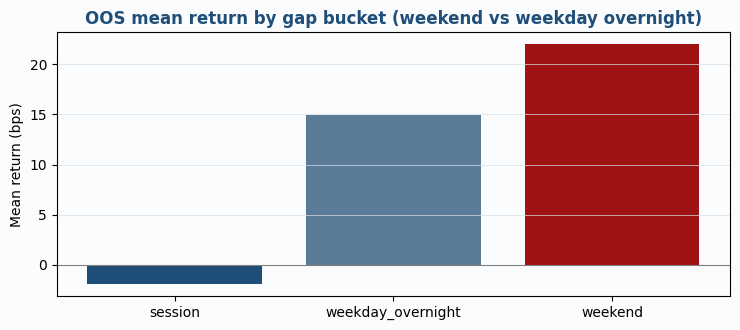

In [24]:
gap = gap_vs_path_decomposition(
    full,
    oos_trades if not oos_trades.empty else oos_res.pair_trades,
    is_end=IS_END,
    use_hedge_ratio_sizing=cfg.use_hedge_ratio_sizing,
)
display(gap)
fig = plot_gap_bucket_means(gap, title="OOS mean return by gap bucket (weekend vs weekday overnight)")
plt.show()


## 18. Dividend / split audit

In [25]:
audit = dividend_split_audit(full, oos_trades if not oos_trades.empty else oos_res.pair_trades)
flagged = audit.loc[audit["n_jump_days"] > 0].sort_values("max_abs_jump", ascending=False)
print(f"trades overlapping large raw jumps: {len(flagged)} / {len(audit)}")
display(flagged.head(20) if not flagged.empty else audit.head())


trades overlapping large raw jumps: 2 / 52


,pair_id,entry_date,exit_date,pnl_pct,n_jump_days,max_abs_jump,tickers_flagged
38,WSO|WSO.B,2026-04-09,2026-04-28,1.107255,1,0.221731,WSO.B
14,WSO|WSO.B,2023-01-12,2023-04-06,-1.718713,1,0.151301,WSO.B


## 19. Fill-timing check

In [26]:
timing = check_fill_timing(
    oos_res.pair_trades if not oos_res.pair_trades.empty else oos_trades,
    oos_panel,
)
display(timing.head())
n_bad = int((~timing["all_ok"]).sum()) if not timing.empty else 0
print(f"fill-timing failures: {n_bad} / {len(timing)}")
if n_bad:
    raise AssertionError(f"{n_bad} trades failed close-t → open-t+1 fill-timing checks")


,pair_id,entry_date,signal_date,ok_signal_before_fill,ok_fill_has_open,ok_not_same_bar_close_fill,ok_z_finite_on_signal,all_ok
0,WSO|WSO.B,2022-01-07,2022-01-06,True,True,True,True,True
1,WSO|WSO.B,2022-01-21,2022-01-20,True,True,True,True,True
2,WSO|WSO.B,2022-02-07,2022-02-04,True,True,True,True,True
3,WSO|WSO.B,2022-03-10,2022-03-09,True,True,True,True,True
4,WSO|WSO.B,2022-04-19,2022-04-18,True,True,True,True,True


fill-timing failures: 0 / 52


## 20. Export + PDF

In [27]:
path = export_s2_period_returns(oos_net, S2_RETURNS_PATH)
print(f"wrote daily S2 net returns -> {path}  n={len(oos_net)}")

base = full_res.returns_base
if base is None or len(base) == 0:
    raise ValueError(
        "full_res.returns_base is empty; cannot export s2_period_returns_base.parquet"
    )
base_path = export_s2_period_returns(base, S2_BASE_PATH)
print(f"wrote daily S2 pre-VT base returns -> {base_path}  n={len(base)}")

write_star_tearsheet_pdf(
    PDF_PATH,
    stack=stack,
    is_end=IS_END,
    full_net=full_net,
    oos_net=oos_net,
    oos_gross=oos_gross,
    headline=headline,
    weekly_full=weekly_full,
    weekly_oos=weekly_oos,
    spy_daily=spy,
    event_returns=full_net,
    health=health,
    attribution=attr,
    worst_trades=worst,
    best_trades=best,
    capacity=cap,
    gap_table=gap,
    sharpe_ci=ci,
    cvar_5=cvar5,
    title="S2 STAR — institutional tearsheet (Universe D)",
)
print(f"wrote desk PDF -> {PDF_PATH}")


wrote daily S2 net returns -> c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_period_returns.parquet  n=1164
wrote daily S2 pre-VT base returns -> c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s2_coint\s2_period_returns_base.parquet  n=9228
wrote desk PDF -> C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_tearsheet.pdf
